### import libraries

In [61]:
from patterson import *

# Uncomment one line below for interactive/zoomable plots:
# %matplotlib widget
# (JupyterLab — requires: pip install ipympl)
# %matplotlib notebook
# (classic Jupyter Notebook)

data_file = example_data  # bundled example: IZO thin film on Si substrate

### plot raw XRR (R/R_F)

C:\Users\h.steinrueck\AppData\Local\miniforge3\envs\JNBenv\Lib\site-packages\patterson\core.py:13: RuntimeWarning: invalid value encountered in sqrt
  (qq - np.sqrt(qq**2 - qc_sq)) / (qq + np.sqrt(qq**2 - qc_sq))


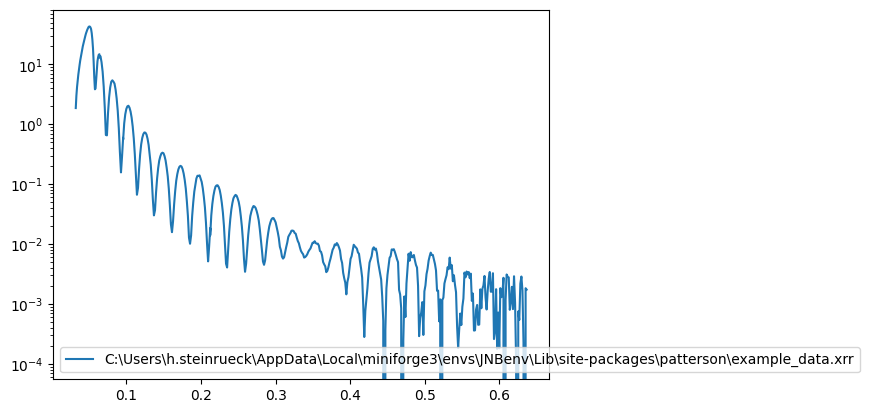

In [62]:
plotXrr(data_file, rho_sub=0.71, rffPlot=True)

### Patterson function — FFT method (fast)

Saved: example_fft.fft


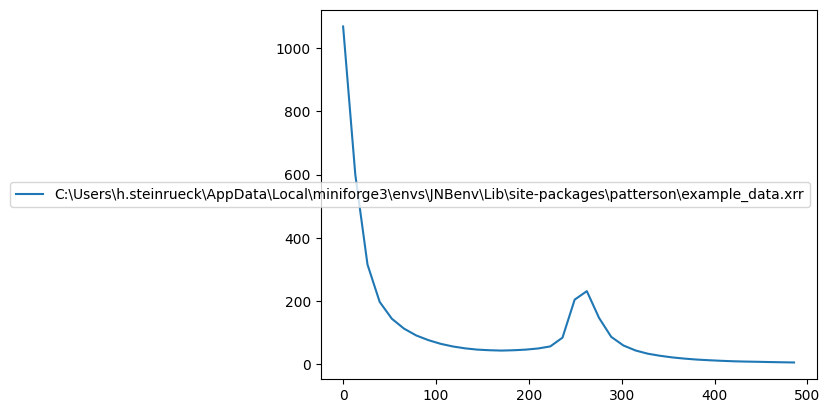

In [63]:
distance_fft, patt_fft = patterson(
    data_file,
    method=0,
    qMin=0.12, qMax=0.6,
    scale = 1., norm=False,
    zCutOff=0, maxZ=500,
    rrfNorm=True,
    rho_pre=0.0, rho_sub=0.71,
    plot=True, logPlot=False,
    save=True,
    meanSub=False, windowFunc=False, padding=False, ax=None,
    outputFile="example_fft")

### Patterson function — manual DFT method (slow, but explicit)

Saved: example_manual.ftMan


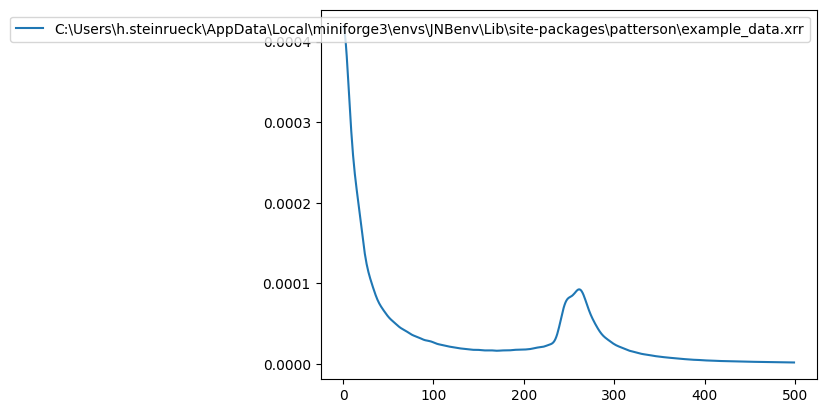

In [64]:
distance_man, patt_man = patterson(
    data_file,
    method=1,
    qMin=0.12, qMax=0.6,
    scale = 1., norm=False,
    zCutOff=0, maxZ=500,
    rrfNorm=True,
    rho_pre=0.0, rho_sub=0.71,
    plot=True, logPlot=False,
    save=True,
    meanSub=False, windowFunc=False, padding=False, ax=None,
    outputFile="example_manual")

### compare FFT and manual DFT side by side

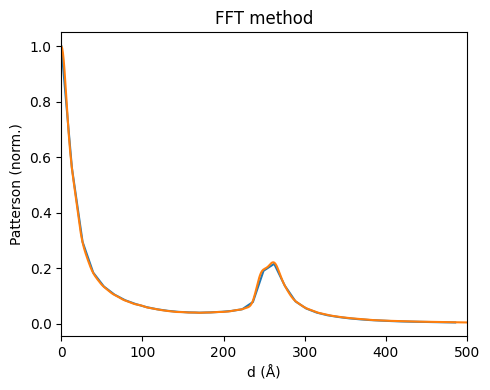

In [65]:
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))

ax1.plot(distance_fft, patt_fft / np.nanmax(patt_fft))
ax1.set_xlabel("d (Å)")
ax1.set_ylabel("Patterson (norm.)")
ax1.set_title("FFT method")
ax1.set_xlim(0, 500)

ax1.plot(distance_man, patt_man / np.nanmax(patt_man))

plt.tight_layout()
plt.show()